PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64
PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageCond        78
GarageYrBlt       78
GarageQual        78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtExposure      44
BsmtQual          44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
BsmtFullBath       2
BsmtHalfBath       2
Functional         2
Utilities          2
GarageCars         1
GarageArea         1
TotalBsmtSF        1
KitchenQual        1
BsmtUnfSF          1


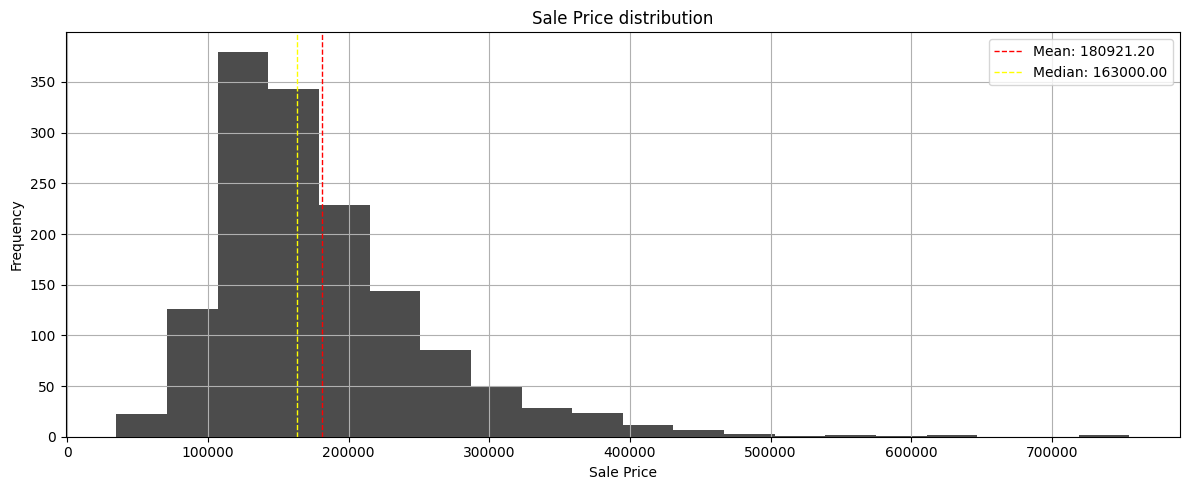

SalePrice after log is symmetrical (mean:12.02, median:12.00)


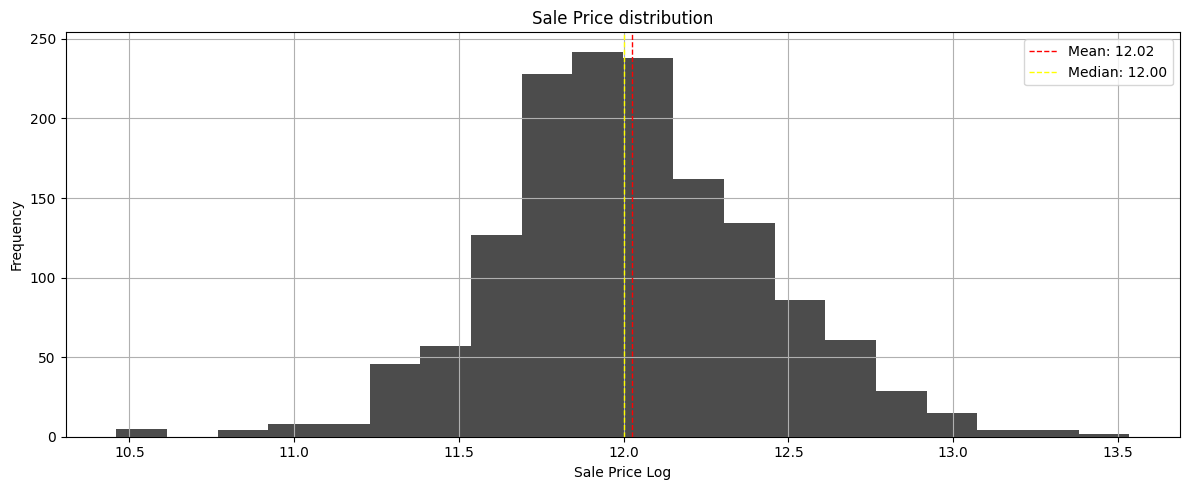

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path
import numpy as np

df_train = pd.read_csv('../data/kaggle_house_prices_train.csv')
df_test = pd.read_csv('../data/kaggle_house_prices_test.csv')

pd.set_option('display.max_rows', None)

# Full list of columns with null values
def get_null_columns(df: pd.DataFrame):
    null_cols = df.isnull().sum()
    null_cols = null_cols[null_cols > 0].sort_values(ascending=False)

    cols_with_nulls = df.columns[df.isnull().any()].tolist()
    # print(cols_with_nulls)
    print(null_cols)

    pd.reset_option('display.max_rows')

get_null_columns(df_train)
get_null_columns(df_test)
salePrices = df_train['SalePrice']


def skew_string(mean:float, median:float):
    return "right skewed" if mean > median * 1.1 else "left_skewd" if mean * 1.1 < median else "symmetrical"


# SalePrice distribution check
print(f"SalePrice is {skew_string(salePrices.mean(),salePrices.median())} (mean:{salePrices.mean():.2f}, median:{salePrices.median():.2f})")

# SalePrice distribution fig
plt.figure(figsize=(12,5))
salePrices.hist(bins=20, color='black',alpha=0.7)
plt.axvline(salePrices.mean(), color='red', linestyle='dashed', linewidth=1,label=f'Mean: {salePrices.mean():.2f}')
plt.axvline(salePrices.median(), color='yellow', linestyle='dashed', linewidth=1,label=f'Median: {salePrices.median():.2f}')
plt.title('Sale Price distribution')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


# Sale price is right skewed apply log transformation

df_train['SalePrice'] = df_train['SalePrice'].apply(lambda x: np.log1p(x))
salePricesLog = df_train['SalePrice']
print(f"SalePrice after log is {skew_string(salePricesLog.mean(),salePricesLog.median())} (mean:{salePricesLog.mean():.2f}, median:{salePricesLog.median():.2f})")

# SalePrice distribution fig after log transformation
plt.figure(figsize=(12,5))
salePricesLog.hist(bins=20, color='black',alpha=0.7)
plt.axvline(salePricesLog.mean(), color='red', linestyle='dashed', linewidth=1,label=f'Mean: {salePricesLog.mean():.2f}')
plt.axvline(salePricesLog.median(), color='yellow', linestyle='dashed', linewidth=1,label=f'Median: {salePricesLog.median():.2f}')
plt.title('Sale Price distribution')
plt.xlabel('Sale Price Log')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()



In [2]:
# preprocess data, feature engineering and one hot coding

def fill_missing(df:pd.DataFrame,cat_none_cols:list[str],num_none_cols:list[str]):
    # Fill  categorical NAs with "None"
    for col in cat_none_cols:
        if col in df.columns:
            df[col] = df[col].fillna("None")
     # Fill  Numerical NAs with 0
    for col in num_none_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # Fill remaining categorical NAs with mode
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    # Fill remaining numerical NAs with mean
    for col in df.select_dtypes(include='number').columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    return df

def engineer_feature(df:pd.DataFrame):
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBathrooms'] = df['FullBath'] + (df['HalfBath'] * 0.5 ) + df['BsmtFullBath'] + (df['BsmtHalfBath'] * 0.5)
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
    df['WasRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['SizeQuality'] = df['TotalSF'] * df['OverallQual']

    skewness = df.select_dtypes(include='number').skew().sort_values(ascending=False)

    # Filter to highly skewed
    high_skew = skewness[skewness.abs() > 0.75].index.tolist()

    # Remove target column
    if 'SalePrice' in high_skew:
        high_skew.remove('SalePrice')

    df[high_skew] = df[high_skew].apply(lambda x: np.log1p(x))

    return df

# Combine train and test data before preprocessing
df_train_size = len(df_train)
combined_df = pd.concat([df_train,df_test],axis=0).reset_index(drop=True)

# categorical NAs columns where NAs means "None"
cat_none_cols = [
    'PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','BsmtFinType2','BsmtExposure','BsmtFinType1','BsmtCond','BsmtQual',
]

# numerical NAs columns where NAs means 0
num_none_cols = [
'GarageYrBlt','MasVnrArea','BsmtFullBath','BsmtHalfBath','GarageCars','GarageArea','TotalBsmtSF','BsmtUnfSF','BsmtFinSF2','BsmtFinSF1'
]
print(combined_df.shape)
print(f"Null columns in combined:{combined_df.isnull().sum().sum()}")
combined_df = fill_missing(combined_df,cat_none_cols,num_none_cols)
print(f"Null columns in combined:{combined_df.isnull().sum().sum()}")
combined_df = engineer_feature(combined_df)
combined_df = pd.get_dummies(data=combined_df,drop_first=True,dtype=int)
print(combined_df.shape)

# split back
train_encoded = combined_df.iloc[:df_train_size].copy()
test_encoded = combined_df.iloc[df_train_size:].copy()

print(f"train encoded shape:{train_encoded.shape}")
print(f"test encoded shape:{test_encoded.shape}")

(2919, 81)
Null columns in combined:17166
Null columns in combined:0
(2919, 267)
train encoded shape:(1460, 267)
test encoded shape:(1459, 267)


/var/folders/vd/nny5h1c50w12z_q275b2qf4r0000gn/T/ipykernel_22582/1452740393.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [3]:
# fitting training data

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

X = train_encoded.drop(columns=['SalePrice','Id'],errors='ignore')
y = train_encoded['SalePrice']
print(y)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

model = XGBRegressor(n_estimators=200, max_depth=4,learning_rate=0.1, random_state=42, eval_metric='logloss', verbosity=0)
model.fit(X_train,y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

def get_model_scores(y_input,y_pred):
    rmse = np.sqrt(mean_squared_error(y_input, y_pred))
    r2   = r2_score(y_input, y_pred)
    return rmse,r2

train_rmse,train_r2 = get_model_scores(y_train, y_pred_train)
test_rmse,test_r2  = get_model_scores(y_test,  y_pred_test)


print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"Train R²:   {train_r2:.4f}")
print(f"Test  R²:   {test_r2:.4f}")


# cross validation

cv_score =  cross_val_score(model,X_train,y_train,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)
print(f"CV RMSE scores: {(-cv_score).round(4)}")
print(f"CV mean and std:{(-cv_score).mean():.3f} ± {(-cv_score).std():.3f}")



0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64
X_train: (1168, 265)
X_test:  (292, 265)
y_train: (1168,)
y_test:  (292,)
Train RMSE: 0.0424
Test  RMSE: 0.1375
Train R²:   0.9882
Test  R²:   0.8987
CV RMSE scores: [0.134  0.1395 0.1416 0.123  0.1126]
CV mean and std:0.130 ± 0.011


In [4]:
# Tune XGBRegressor

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100,200,300,400],
    'max_depth':[3,4,5],
    'learning_rate':[0.05,0.1,0.2],
    'subsample':[0.8,1.0],
    'colsample_bytree': [0.7, 0.8],
}

gridSearch = GridSearchCV(estimator=XGBRegressor(random_state=42,eval_metric='logloss',verbosity=0),param_grid=param_grid,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)
gridSearch.fit(X_train,y_train)
print(f"Best parameters: {gridSearch.best_params_}")
print(f"Best cross-validation accuracy: {-(gridSearch.best_score_):.3f}")


best_model = gridSearch.best_estimator_
y_pred = best_model.predict(X_test)
best_model_rmse, best_model_r2= get_model_scores(y_test,y_pred)

print(f"Best Model RMSE: {best_model_rmse:.4f}")
print(f"Best Model R²:   {best_model_r2:.4f}")
print(f"Best Model feature important:{best_model.feature_importances_}")


Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
Best cross-validation accuracy: 0.124
Best Model RMSE: 0.1343
Best Model R²:   0.9033
Best Model feature important:[0.00098372 0.00238994 0.00442133 0.02023935 0.00720321 0.00708238
 0.00979641 0.00106076 0.00429919 0.00121383 0.00363396 0.00197408
 0.00253837 0.00469741 0.00091425 0.00487891 0.00230208 0.00243825
 0.00209931 0.00152888 0.0027687  0.02075066 0.00144857 0.01983003
 0.00564325 0.03090393 0.00557119 0.00179953 0.00360291 0.00120496
 0.00079563 0.0022624  0.00404734 0.00061032 0.00134279 0.00131372
 0.08914245 0.02549989 0.01618929 0.01411743 0.00091664 0.2104335
 0.00154837 0.00101931 0.00056981 0.02862191 0.         0.00141226
 0.0004072  0.00131635 0.00070511 0.00517407 0.00331864 0.00034322
 0.00321902 0.         0.00186859 0.00106936 0.         0.00076625
 0.00110667 0.         0.         0.         0.00141563 0.00248735
 0.00048359 0.00468875 0.006

In [5]:
# Predict on test data

# retrain model on full training data before predicting on test
best_model.fit(X,y)
print(f"Best parameters: {gridSearch.best_params_}")
print(f"Best cross-validation accuracy: {-(gridSearch.best_score_):.3f}")

# predict on test data

test_ids = pd.read_csv('../data/kaggle_house_prices_test.csv')['Id']
test_encoded = test_encoded.drop(columns=['SalePrice','Id'], errors='ignore')
test_preds_log = best_model.predict(test_encoded)

test_preds = np.expm1(test_preds_log)

# create submission
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice':test_preds
})
submission.to_csv('outputs/house_prices_submission.csv', index=False)
print(submission.head())
print(f"Shape: {submission.shape}")
print(f"Price range: ${submission['SalePrice'].min():,.0f} to ${submission['SalePrice'].max():,.0f}")


Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
Best cross-validation accuracy: 0.124
     Id      SalePrice
0  1461  127414.898438
1  1462  163842.687500
2  1463  185108.562500
3  1464  193320.078125
4  1465  183838.531250
Shape: (1459, 2)
Price range: $47,952 to $504,488


In [6]:
# Feature selection

feature_importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

threshold = 0.003
high_imp     = feature_importances[feature_importances >= threshold].index.tolist()
print(f"High importance features: {high_imp}")

X_selected = X[high_imp]
test_selected = test_encoded[high_imp]

# This creates a brand new model with the same parameters
final_model = XGBRegressor(**gridSearch.best_params_, random_state=42, verbosity=0)
final_model.fit(X_selected, y)

# evaluate
cv_scores = cross_val_score(
    final_model, X_selected, y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
print(f"CV RMSE after selection: {(-cv_scores).mean():.4f}")

final_model_preds_log = final_model.predict(test_selected)
final_model_preds = np.expm1(final_model_preds_log)

# create submission
final_submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice':final_model_preds
})
final_submission.to_csv('outputs/house_prices_feature_selection_submission.csv', index=False)
print(final_submission.head())
print(f"Shape: {final_submission.shape}")
print(f"Price range: ${final_submission['SalePrice'].min():,.0f} to ${final_submission['SalePrice'].max():,.0f}")


High importance features: ['SizeQuality', 'TotalSF', 'CentralAir_Y', 'FireplaceQu_None', 'GarageCars', 'TotalBathrooms', 'GarageCond_TA', 'MSZoning_RM', 'OverallQual', 'GarageQual_TA', 'KitchenQual_TA', 'KitchenAbvGr', 'KitchenQual_Gd', 'LotShape_Reg', 'Fireplaces', 'GarageType_Detchd', 'YearsSinceRemodel', 'Neighborhood_Edwards', 'BsmtFinType1_Unf', 'MSZoning_RL', 'LandSlope_Mod', 'YearBuilt', 'Heating_GasA', 'OverallCond', 'MiscFeature_None', 'PoolQC_None', 'BsmtExposure_No', 'BsmtQual_TA', 'YearRemodAdd', 'Functional_Typ', 'HouseAge', 'BsmtFinType1_LwQ', 'GarageYrBlt', 'GarageFinish_Unf', 'BsmtFinType1_GLQ', 'Neighborhood_Crawfor', 'Neighborhood_IDOTRR', '2ndFlrSF', 'Neighborhood_OldTown', 'BsmtExposure_Gd', 'Condition1_PosN', 'PavedDrive_Y', 'SaleCondition_Normal', 'Neighborhood_NAmes', 'ExterCond_Fa', '1stFlrSF', 'BsmtFinSF1', 'GrLivArea', 'GarageArea', 'LotArea', 'BsmtQual_Gd', 'SaleCondition_Partial', 'BsmtUnfSF', 'Fence_GdWo', 'SaleType_New', 'KitchenQual_Fa']
CV RMSE after sel

In [ ]:
import joblib 

# Save model
joblib.dump(final_model, 'outputs/kaggle_house_prices_prediction_model.pkl')


['outputs/kaggle_house_prices_prediction_model.pkl']